In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import  DataLoader,Subset
import torch.optim as optim
from torchsummary import summary
import torch.nn.functional as F
from torch.autograd.functional import jacobian
from torchvision import transforms,datasets
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE 
import pandas as pd
import time
device= torch.device ('cuda'if torch.cuda.is_available() else 'cpu')


In [3]:
transform=transforms.Compose([transforms.Resize((64,64)),
                              transforms.ToTensor(),
                              transforms.Normalize((0.5),
                                                   (0.5))])
train_dataset=datasets.MNIST(root='data',
                             train=True,
                             download=True,
                             transform=transform)

subset_indices=list(range(5000))
subset_data_set=Subset(train_dataset,subset_indices)

data_loader = DataLoader(subset_data_set,batch_size=100,shuffle=True)


In [12]:
class UnetAutoEncoder(nn.Module):
  def __init__(self,input_features):
    super().__init__()
    #Encoder
    self.encoder_=nn.Sequential(
        #Encoder 1
        nn.Conv2d(input_features,64,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(64,64,kernel_size=3,padding=1),
        nn.ReLU(),

        #Encoder 2
        nn.MaxPool2d(2),
        nn.Conv2d(64,128,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(128,128,kernel_size=3,padding=1),
        nn.ReLU(),

        #Encoder 3
        nn.MaxPool2d(2),
        nn.Conv2d(128,256,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(256,256,kernel_size=3,padding=1),
        nn.ReLU(),

        #Encoder 4
        nn.MaxPool2d(2),
        nn.Conv2d(256,512,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(512,512,kernel_size=3,padding=1),
        nn.ReLU()
    )

    #Bottleneck
    self.bottleneck_=nn.Sequential(
        nn.MaxPool2d(2),
        nn.Conv2d(512,1024,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(1024,1024,kernel_size=3,padding=1),
        nn.ReLU()
    )
    #Decoder
    self.decoder_= nn.Sequential(#Decoder 1
            nn.ConvTranspose2d(1024,512,kernel_size=2,stride=2),
            nn.Conv2d(512,512,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(512,512,kernel_size=3,padding=1),
            nn.ReLU(),

            #Decoder 2
            nn.ConvTranspose2d(512,256,kernel_size=2,stride=2),
            nn.Conv2d(256,256,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(256,256,kernel_size=3,padding=1),
            nn.ReLU(),

            #Decoder 3
            nn.ConvTranspose2d(256,128,kernel_size=2,stride=2),
            nn.Conv2d(128,128,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(128,128,kernel_size=3,padding=1),
            nn.ReLU(),

            #Decoder 4
            nn.ConvTranspose2d(128,64,kernel_size=2,stride=2),
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.ReLU(),

            #output Layer
            nn.Conv2d(64,1,kernel_size=1)
            )

  def forward(self,x):
    self.activation=[] #Cache activation
    self.w_squarred=[] #Cache weight Norms

    current_x=x

    for layer in self.encoder_:
            if isinstance (layer,nn.Conv2d):
                current_x=layer(current_x)
                w=layer.weight
                self.w_squarred=w.pow(2).sum([1,2,3]) #output channels
            elif isinstance(layer,nn.ReLU):
                current_x=layer(current_x)
                self.activation.append(current_x)
            elif isinstance(layer,nn.MaxPool2d):
                current_x=layer(current_x)
            else:
                current_x=layer(current_x)  

    x=current_x
    encoder=x.clone()
    x=self.bottleneck_(x)
    x=self.decoder_(x)
    return(x,encoder)

  # Encoder
  def encoder(self,x):
    x=self.encoder_(x)    
    return(x)

  # Bottleneck
  def bottleneck(self,x):
    x=self.bottleneck_(x)
    # print('bottleneck')
    return(x)

  #Decoder
  def decoder (self,x):
    x=self.decoder_(x)
    return x


In [13]:
class ContractiveAutoEncoder(UnetAutoEncoder):
    def __init__(self,in_dim,s_lambda=1e-6,xavier_nprm_init=True):
        super().__init__(in_dim)
        self.jacobian_lambda=s_lambda
        self.xavier_nprm_init=xavier_nprm_init
        # if self.xavier_nprm_init:
        #     nn.init.xavier_uniform_(self.encoder_.weight)
        #     nn.init.xavier_uniform_(self.encoder_.bias,0)
    '''This code to find the jacobian is computationally demanding as our dataset is big, so we have come up with an approximation of the jacobian which is below
        
        def jacobian_penalty(self,input):
            jacobian_matrix=jacobian(self.encoder_,input)
            epsilon= 1e-3
            jacobain_square=jacobian_matrix.pow(2)        
            jacobian_penalty=jacobain_square.sum()

            return self.jacobian_lambda*jacobian_penalty
    We cannot use the below also as it is also taking more time, 
    lets calculate the contractive loss function using   the cached activation defiined in forward function instead of recomputing them
    
    def contractive_loss_approximation(self,x):
        penalty=0.0
        current_x=x

        for layer in self.encoder_:
            if isinstance (layer,nn.Conv2d):
                current_x=layer(current_x)
                w=layer.weight
                w_squarred=w.pow(2).sum([1,2,3]) #output channels
            elif isinstance(layer,nn.ReLU):
                act_deriv=(current_x>0).float()
                penalty +=(act_deriv.pow(2)*w_squarred.view(1,-1,1,1)).sum()
                current_x=layer(current_x)
            elif isinstance(layer,nn.MaxPool2d):
                current_x=layer(current_x)
            else:
                current_x=layer(current_x)
            
        penalty=self.jacobian_lambda*penalty/x.size(0)
        return penalty
    '''
    def contractive_loss_approximation(self):
        penalty=0

        #Iterate throught the cached activation and W_squarred
        for act,w_sq in zip(self.activation,self.w_squarred):
            act_deriv=(act>0).float()
            penalty+=(act_deriv.pow(2)*w_sq.view(1,-1,1,1)).sum()
        penalty=self.jacobian_lambda*penalty/act.size(0)
        return(penalty)

        
    

    def loss_function(self,x_hat,x):
        mse=F.mse_loss(x_hat,x)
        contractive_loss=self.contractive_loss_approximation()
        # print(f'MSE={mse}')
        # print(f'Sparsity={contractive_loss}')
        return mse+contractive_loss

In [6]:
#Train the model
def train_model(model,dataloader,epochs,optimizer):
    for epoch in range(epochs):
        total_loss=0
        for records,_ in dataloader:
            records=records.to(device)
            optimizer.zero_grad()
            decoded,encoded=model.forward(records)
            loss=model.loss_function(decoded,records)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss+=loss.item()
            # print(total_loss)
        print(f'Epoch: {epoch+1}/{epochs}- Train L: {float(total_loss/len(data_loader))}')

In [6]:
model=ContractiveAutoEncoder(1)
model.to(device)
optimizer = optim.Adam(model.parameters(),lr=0.0005)
epochs=20

In [10]:
train_model(model,data_loader,epochs,optimizer)

Epoch: 1/20- Train L: 0.46048207104206085
Epoch: 2/20- Train L: 0.2560081991553307
Epoch: 3/20- Train L: 0.17780788660049437
Epoch: 4/20- Train L: 0.10214325942099095
Epoch: 5/20- Train L: 0.05951483622193336
Epoch: 6/20- Train L: 0.03863103035837412
Epoch: 7/20- Train L: 0.027197215147316454
Epoch: 8/20- Train L: 0.022655044458806516
Epoch: 9/20- Train L: 0.018450300320982934
Epoch: 10/20- Train L: 0.017054959274828432
Epoch: 11/20- Train L: 0.013808061312884092
Epoch: 12/20- Train L: 0.012989324145019054
Epoch: 13/20- Train L: 0.01198531612753868
Epoch: 14/20- Train L: 0.012306473590433598
Epoch: 15/20- Train L: 0.010779114905744791
Epoch: 16/20- Train L: 0.009841162841767073
Epoch: 17/20- Train L: 0.00863685755059123
Epoch: 18/20- Train L: 0.009286770708858966
Epoch: 19/20- Train L: 0.008410882465541362
Epoch: 20/20- Train L: 0.007797342222183943


In [12]:
torch.save(model.state_dict(),'Unet_Contractive_autoencoder.pkl')

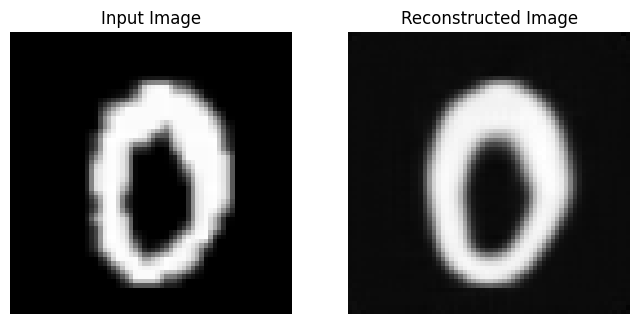

In [ ]:
# Get one sample
data_loader1 = DataLoader(subset_data_set,batch_size=1,shuffle=True)
data_iter = iter(data_loader1)
img, label = next(data_iter)  # img shape: (1,1,64,64)

# Pass through model
model.eval()
with torch.no_grad():
    output, _ = model(img)

# Prepare for plotting
input_img = img.squeeze().cpu().numpy()
output_img = output.squeeze().cpu().numpy()

# De-normalize if needed (from [-1,1] back to [0,1])
input_img = (input_img * 0.5) + 0.5
output_img = (output_img * 0.5) + 0.5

# Plot side by side
plt.figure(figsize=(8,4))

# Input
plt.subplot(1,2,1)
plt.imshow(input_img, cmap='gray')
plt.title("Input Image")
plt.axis('off')

# Output
plt.subplot(1,2,2)
plt.imshow(output_img, cmap='gray')
plt.title("Reconstructed Image")
plt.axis('off')

plt.show()

## (a) (20 points) Plot the t-sne (use inbuilt function) on the embeddings obtained using the respective auto-encoders. Color the clusters using the respective ground-truth class labels.

In [14]:
model=ContractiveAutoEncoder(1)
model.load_state_dict(torch.load('Unet_Contractive_autoencoder.pkl'))

<All keys matched successfully>

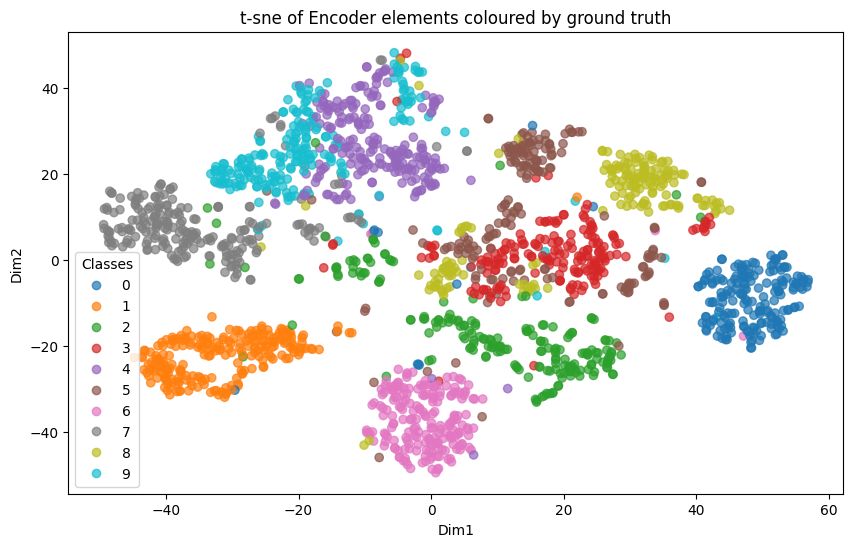

In [15]:
subset_indices=list(range(2000))
subset_data_set=Subset(train_dataset,subset_indices)
data_loader_eval = DataLoader(subset_data_set,batch_size=100,shuffle=True)
embeddings= []
labels=[]

model.eval()
with torch.no_grad():
    for data,label in data_loader_eval:
        data.to(device)

        # encoder Embeddings
        encoder_embeddings=model.encoder(data)

        #Flatening the sample for t-sne
        encoder_embeddings_flattened=encoder_embeddings.view(encoder_embeddings.size(0),-1)

        embeddings.append(encoder_embeddings_flattened)
        labels.append(label)

#concatinate the embeddings and labels
embeddings=torch.cat(embeddings,dim=0)
labels=torch.cat(labels,dim=0)

#Apply t-sne
tsne= TSNE(n_components=2,random_state=42)
embeddings_in_2d=tsne.fit_transform(embeddings.detach().numpy())

#Plot
plt.figure(figsize=(10,6))
scatter=plt.scatter(embeddings_in_2d[:,0],embeddings_in_2d[:,1],c=labels,cmap='tab10',alpha=0.7)
plt.legend(*scatter.legend_elements(),title='Classes')
plt.title('t-sne of Encoder elements coloured by ground truth')
plt.xlabel('Dim1')
plt.ylabel('Dim2')
plt.show()

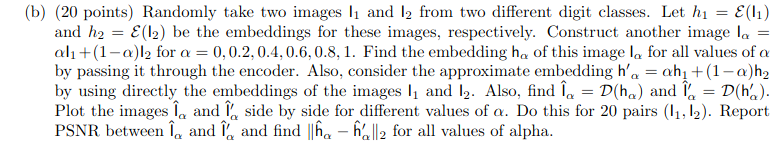

In [9]:
subset_indices=list(range(100))
subset_data_set=Subset(train_dataset,subset_indices)
data_loader_q2 = DataLoader(subset_data_set,batch_size=2,shuffle=True)

In [16]:
def calculate_psnr(img1,img2,max_value=1):
    '''The images are tensors of same dimension with values [0,1]'''
    mse=torch.mean((img1-img2)**2)
    if mse==0:
        return float('inf')
    else:
        psnr_value=20*torch.log10(max_value/mse)
    return psnr_value
def l2norm(img1,img2):
    l2diff=torch.norm(img1-img2,p=2)
    return l2diff


--------------------------------> For the image Pair 1 <--------------------------------



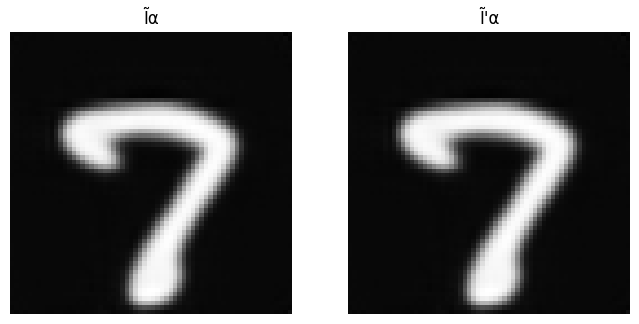

PSNR Value inf ----- L2 value 0.0


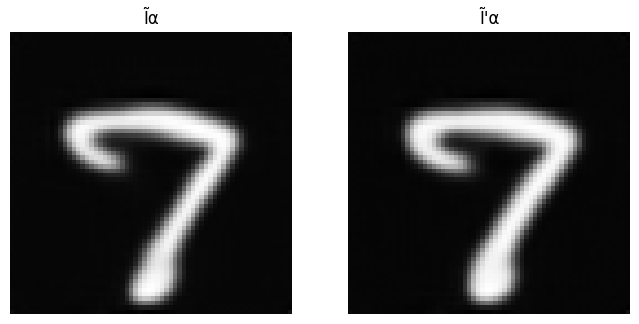

PSNR Value 38.17889404296875 ----- L2 value 7.107346534729004


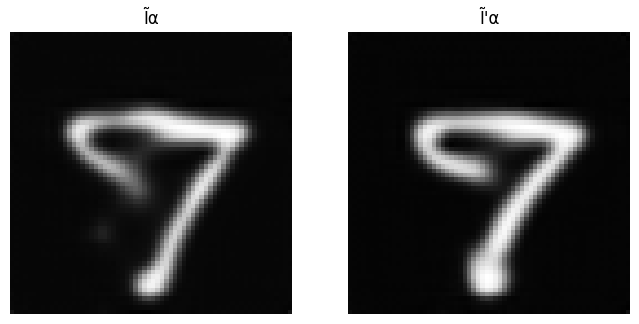

PSNR Value 24.240734100341797 ----- L2 value 15.854828834533691


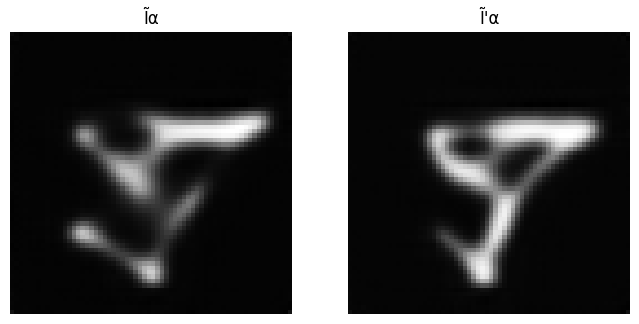

PSNR Value 25.013595581054688 ----- L2 value 15.164917945861816


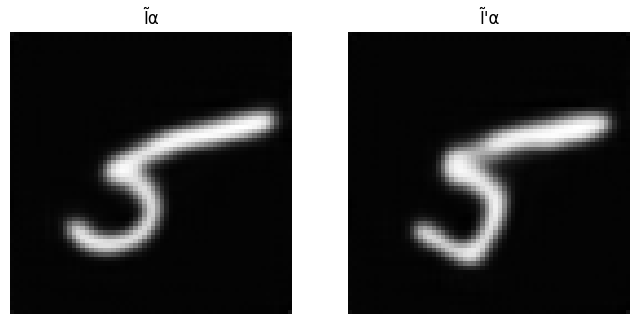

PSNR Value 29.900941848754883 ----- L2 value 11.44606876373291


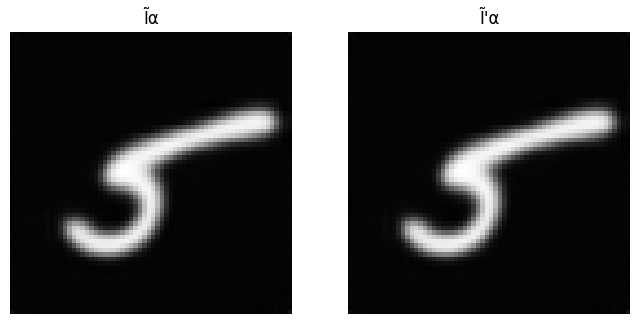

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 2 <--------------------------------



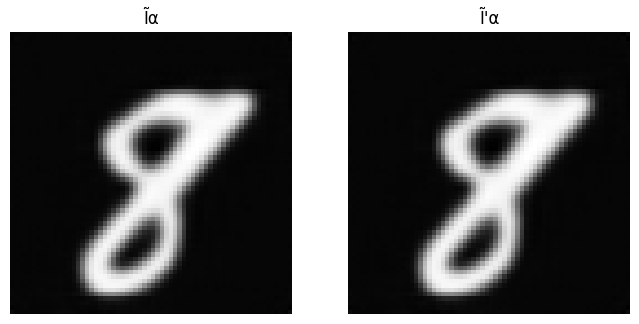

PSNR Value inf ----- L2 value 0.0


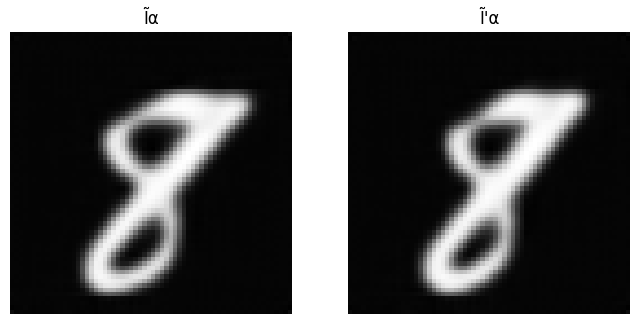

PSNR Value 40.629974365234375 ----- L2 value 6.172065258026123


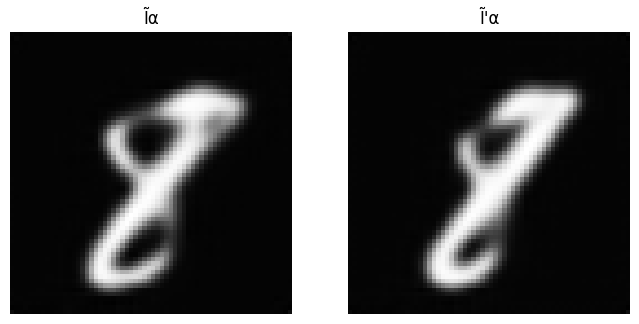

PSNR Value 30.457822799682617 ----- L2 value 11.084962844848633


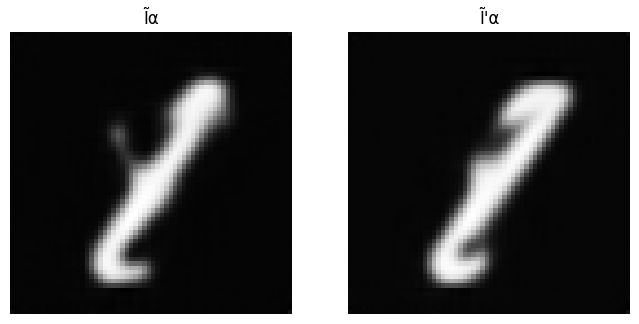

PSNR Value 34.28927993774414 ----- L2 value 8.89094352722168


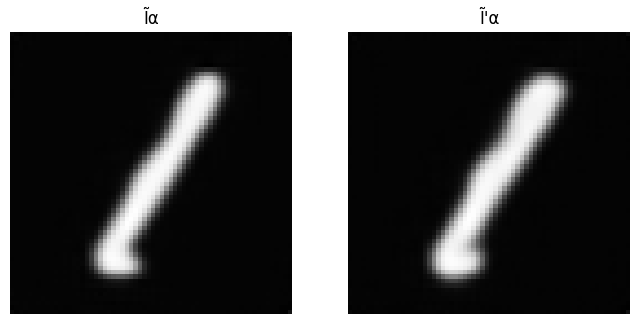

PSNR Value 43.817047119140625 ----- L2 value 5.137521743774414


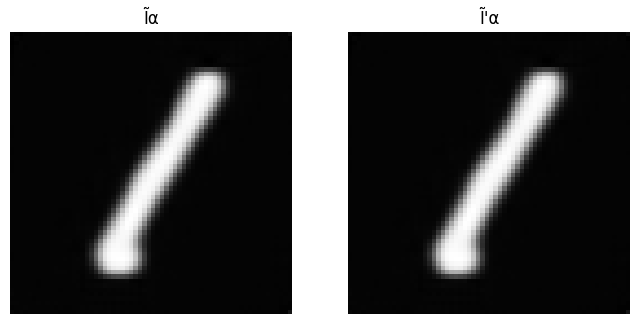

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 3 <--------------------------------



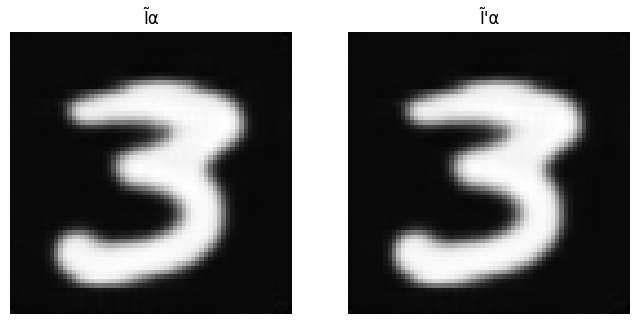

PSNR Value inf ----- L2 value 0.0


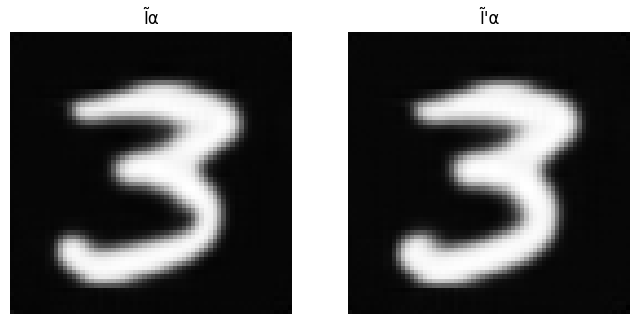

PSNR Value 37.89125442504883 ----- L2 value 7.226010322570801


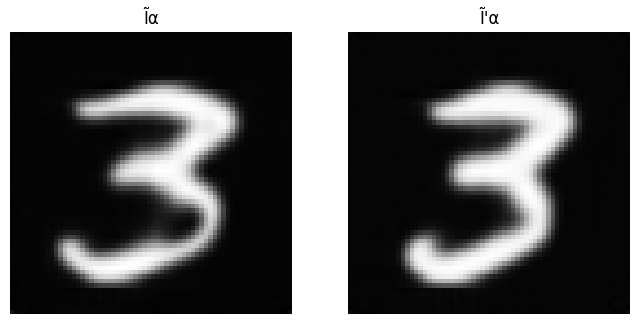

PSNR Value 26.08976173400879 ----- L2 value 14.253973960876465


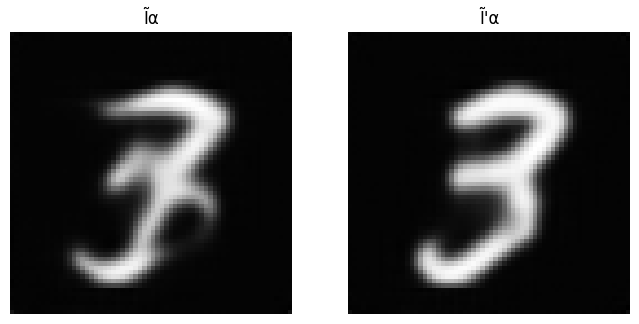

PSNR Value 22.4993896484375 ----- L2 value 17.526498794555664


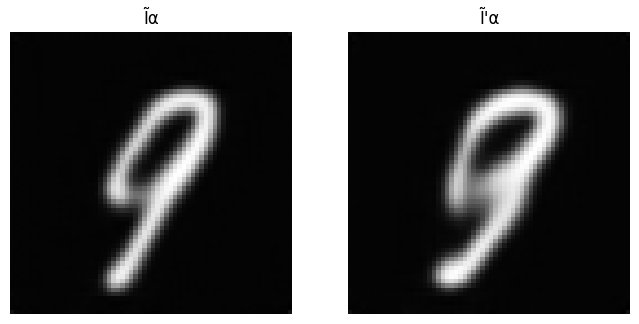

PSNR Value 28.91897201538086 ----- L2 value 12.111712455749512


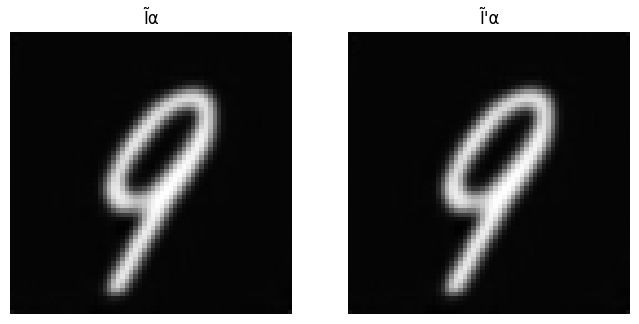

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 4 <--------------------------------



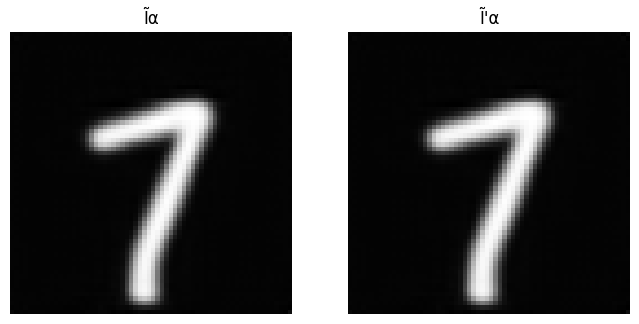

PSNR Value inf ----- L2 value 0.0


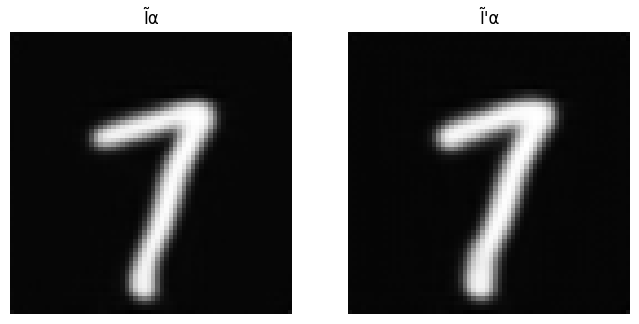

PSNR Value 45.05891799926758 ----- L2 value 4.783071517944336


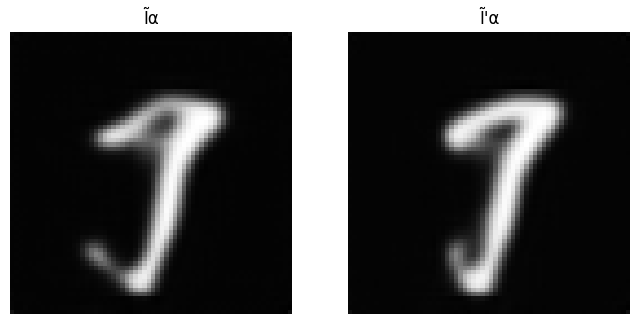

PSNR Value 35.85699462890625 ----- L2 value 8.123720169067383


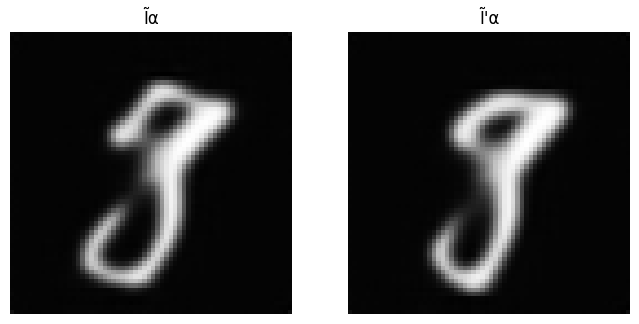

PSNR Value 29.268272399902344 ----- L2 value 11.870610237121582


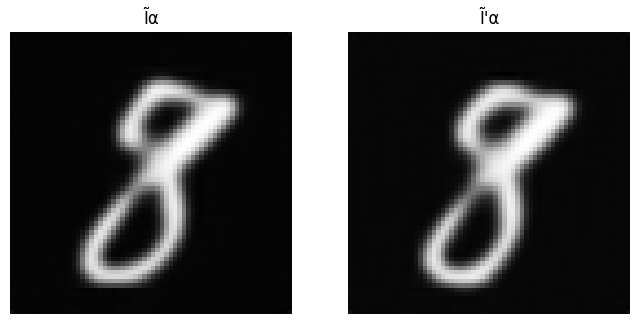

PSNR Value 39.490291595458984 ----- L2 value 6.590564250946045


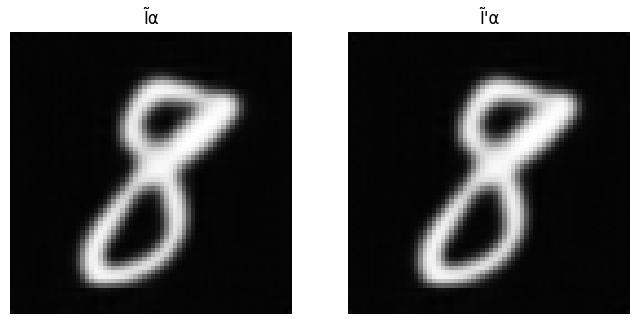

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 5 <--------------------------------



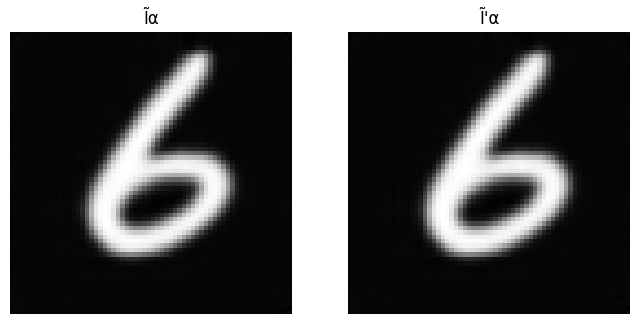

PSNR Value inf ----- L2 value 0.0


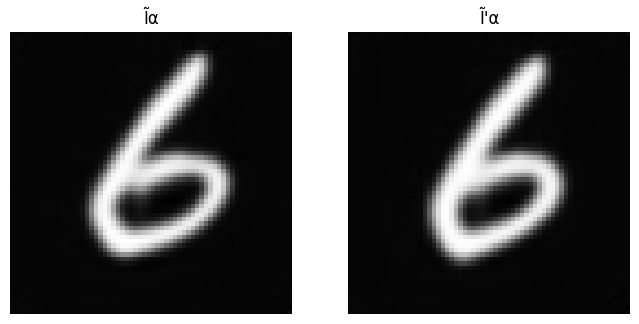

PSNR Value 37.69755935668945 ----- L2 value 7.307029724121094


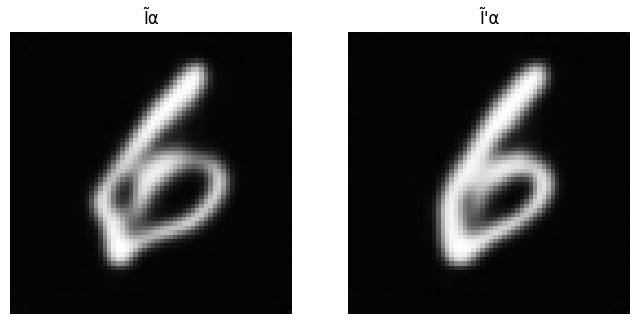

PSNR Value 26.468799591064453 ----- L2 value 13.946329116821289


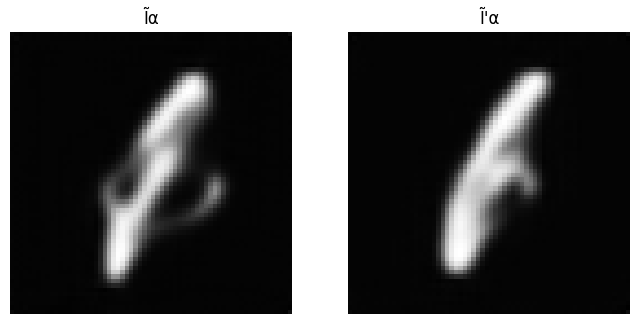

PSNR Value 30.719213485717773 ----- L2 value 10.91942024230957


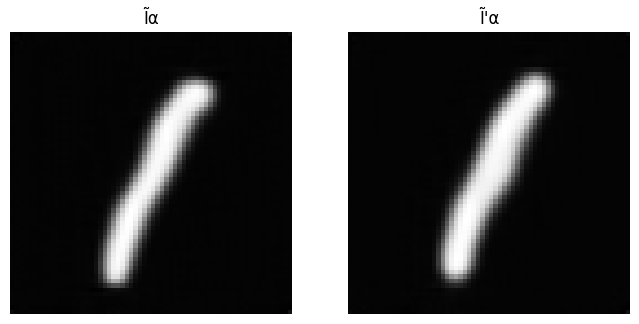

PSNR Value 43.87322235107422 ----- L2 value 5.120934009552002


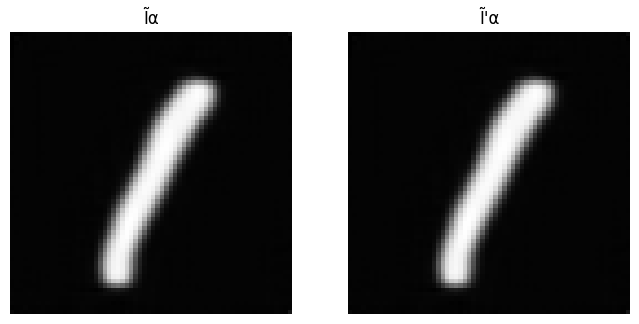

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 6 <--------------------------------



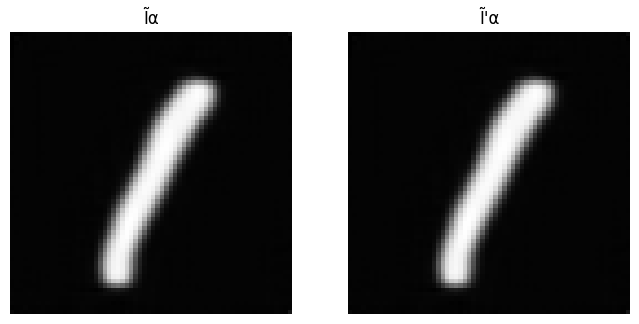

PSNR Value inf ----- L2 value 0.0


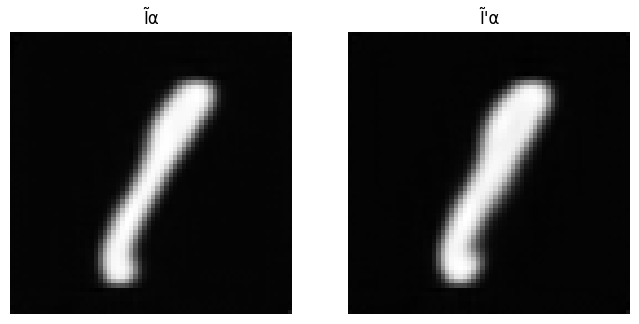

PSNR Value 40.146583557128906 ----- L2 value 6.346222400665283


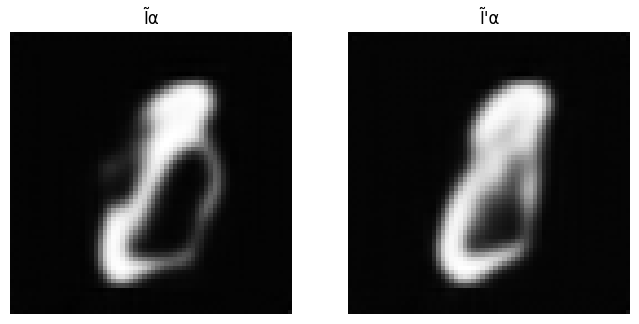

PSNR Value 26.118879318237305 ----- L2 value 14.230098724365234


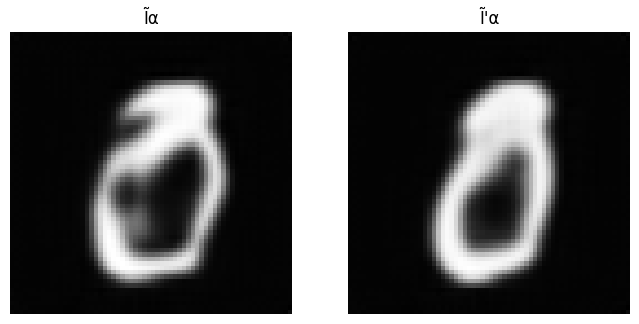

PSNR Value 21.976301193237305 ----- L2 value 18.062271118164062


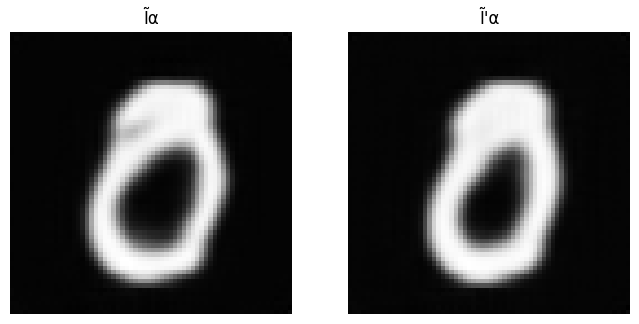

PSNR Value 34.402469635009766 ----- L2 value 8.833200454711914


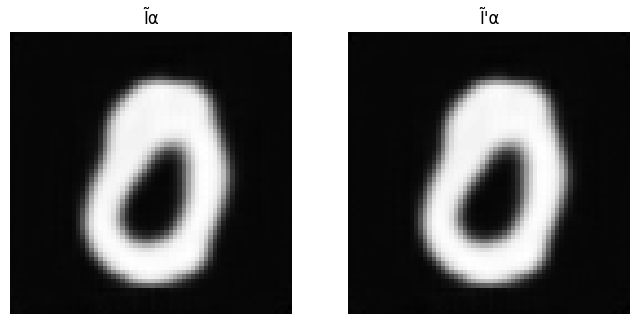

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 7 <--------------------------------



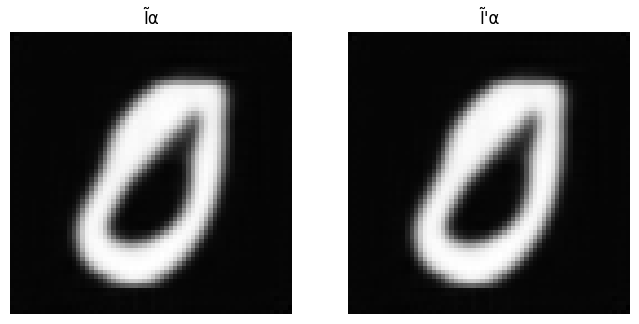

PSNR Value inf ----- L2 value 0.0


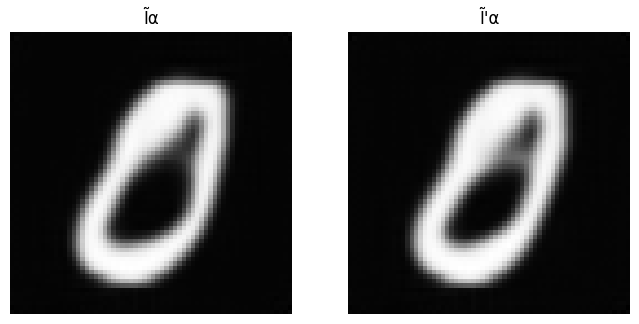

PSNR Value 38.04427719116211 ----- L2 value 7.162636756896973


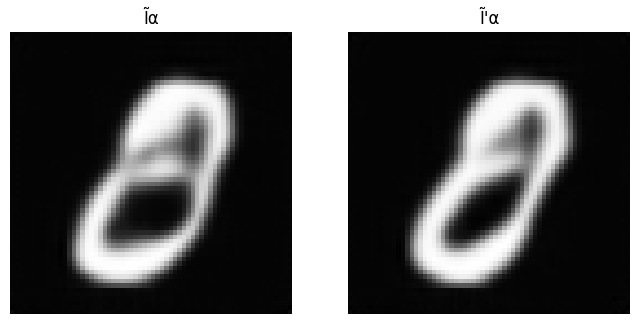

PSNR Value 29.823673248291016 ----- L2 value 11.497091293334961


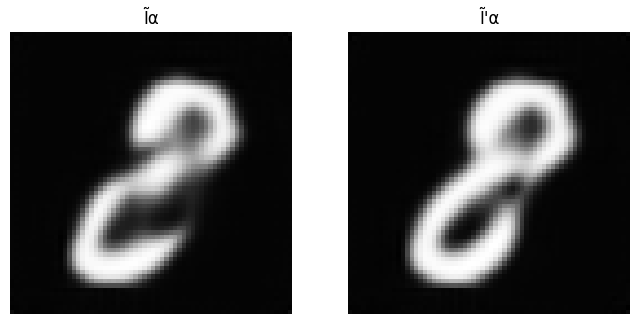

PSNR Value 29.450719833374023 ----- L2 value 11.74659252166748


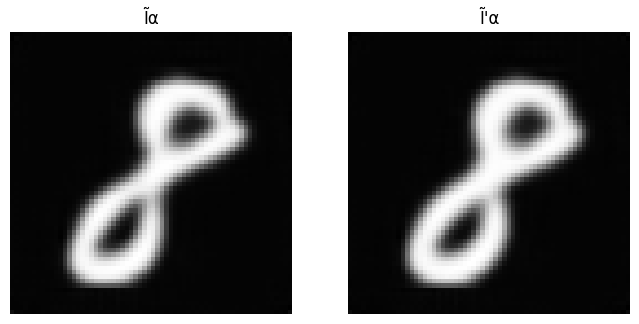

PSNR Value 39.298973083496094 ----- L2 value 6.663547992706299


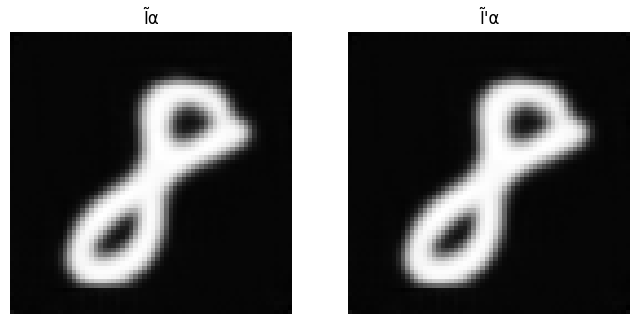

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 8 <--------------------------------



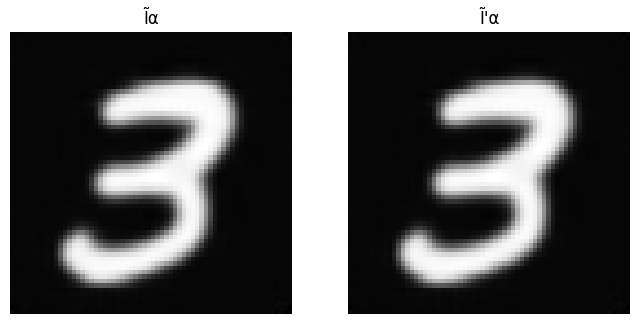

PSNR Value inf ----- L2 value 0.0


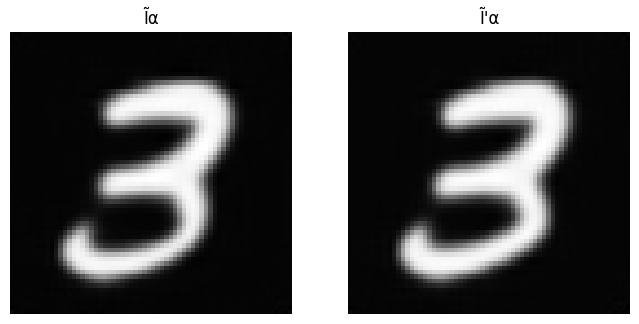

PSNR Value 41.63005447387695 ----- L2 value 5.826778888702393


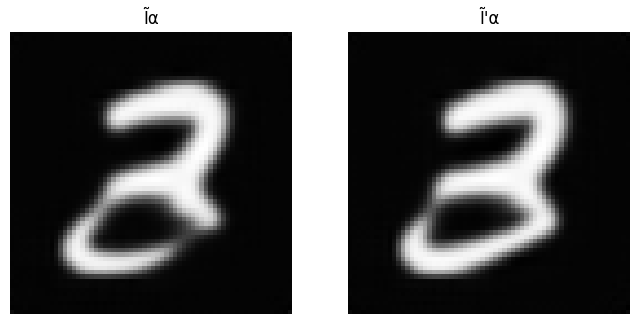

PSNR Value 28.017169952392578 ----- L2 value 12.757061004638672


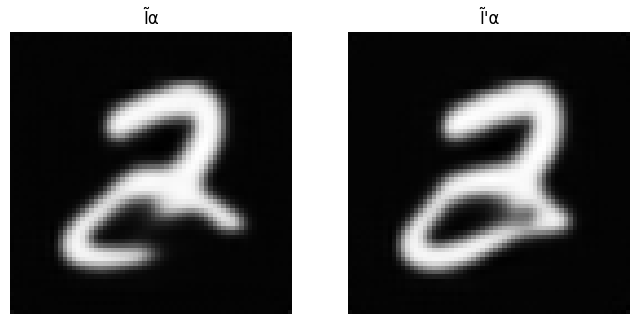

PSNR Value 25.756881713867188 ----- L2 value 14.529742240905762


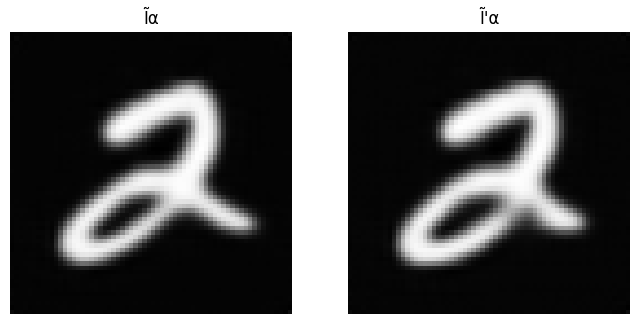

PSNR Value 35.99790954589844 ----- L2 value 8.058090209960938


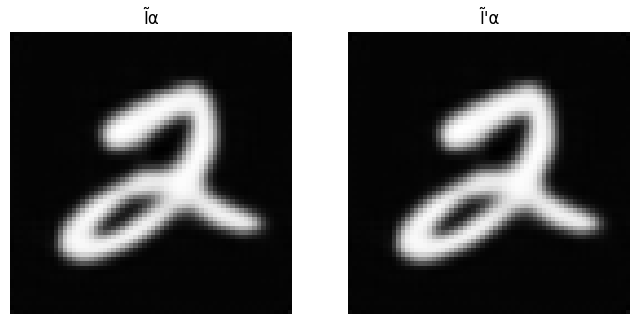

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 9 <--------------------------------



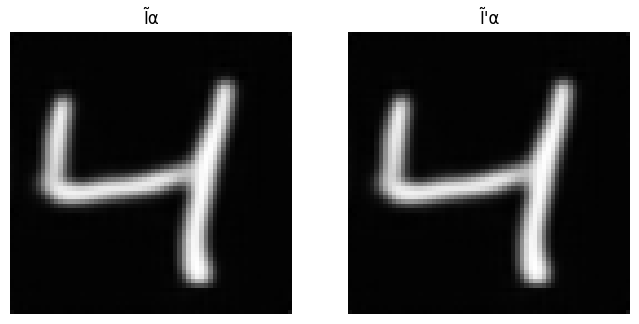

PSNR Value inf ----- L2 value 0.0


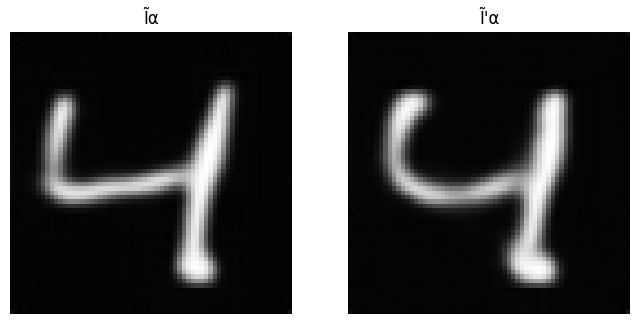

PSNR Value 28.13214874267578 ----- L2 value 12.672904014587402


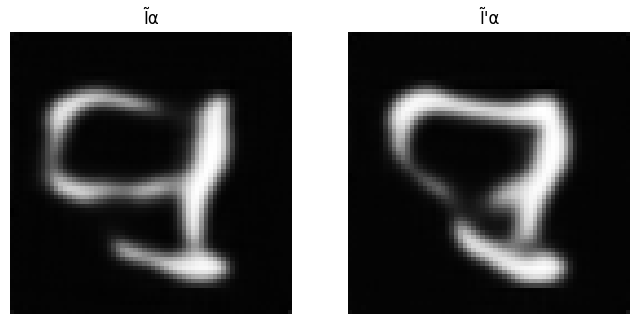

PSNR Value 21.245773315429688 ----- L2 value 18.838029861450195


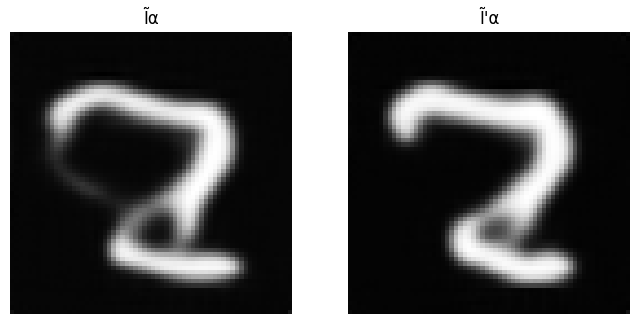

PSNR Value 29.031627655029297 ----- L2 value 12.033425331115723


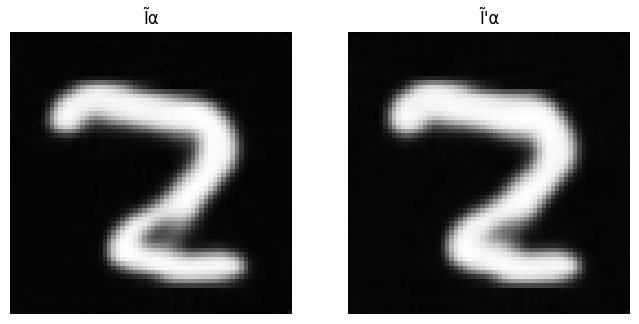

PSNR Value 41.51655578613281 ----- L2 value 5.864973068237305


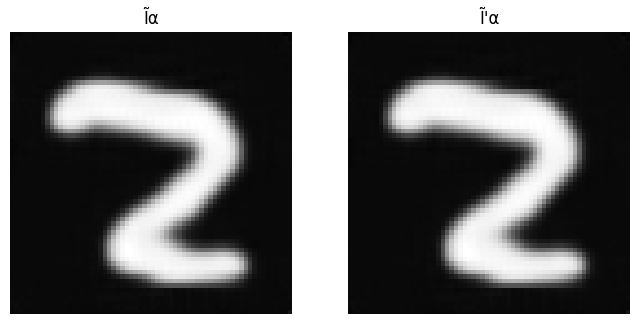

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 10 <--------------------------------



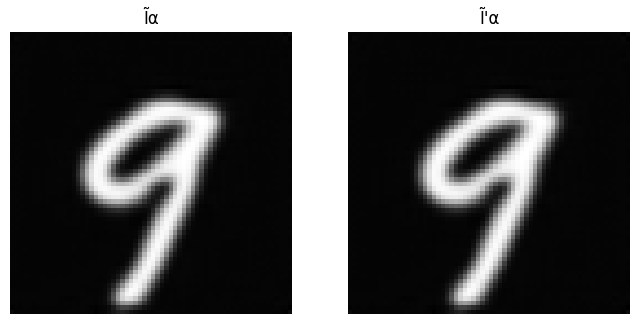

PSNR Value inf ----- L2 value 0.0


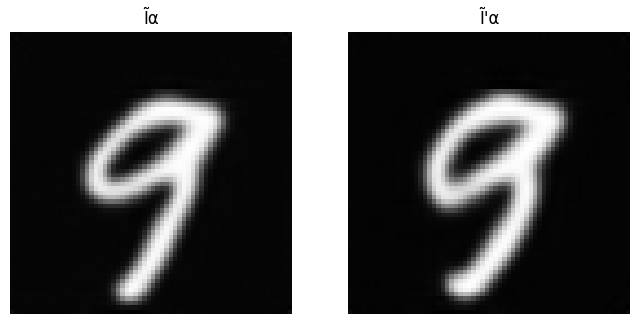

PSNR Value 32.5268669128418 ----- L2 value 9.840295791625977


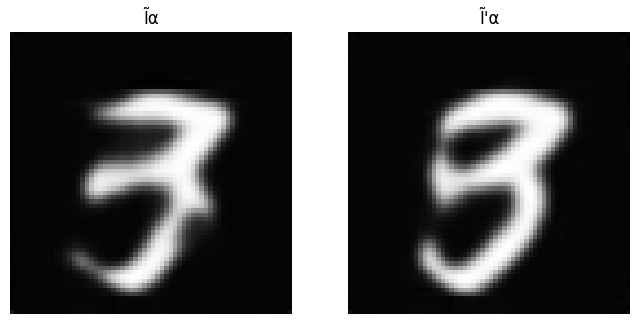

PSNR Value 26.895870208740234 ----- L2 value 13.607649803161621


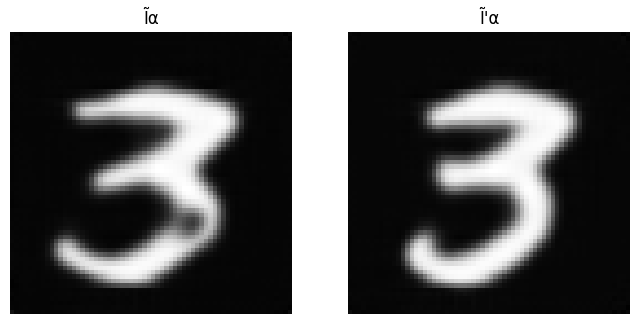

PSNR Value 27.6118106842041 ----- L2 value 13.05823802947998


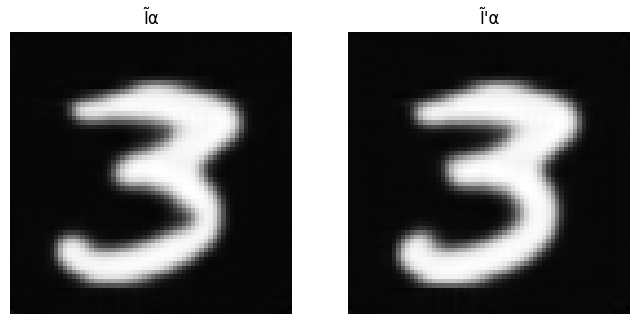

PSNR Value 38.69514465332031 ----- L2 value 6.899240016937256


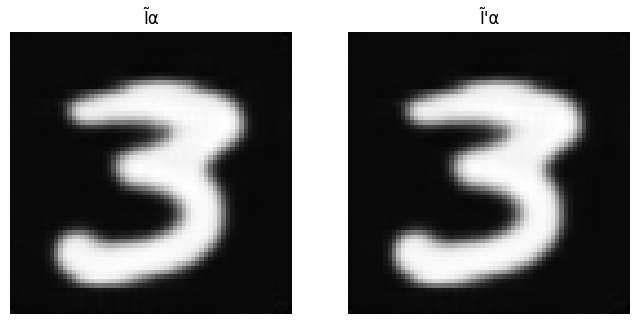

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 11 <--------------------------------



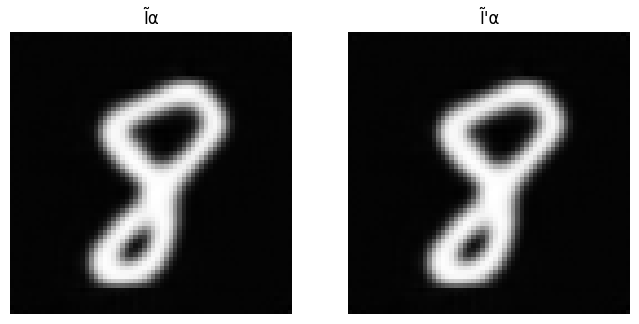

PSNR Value inf ----- L2 value 0.0


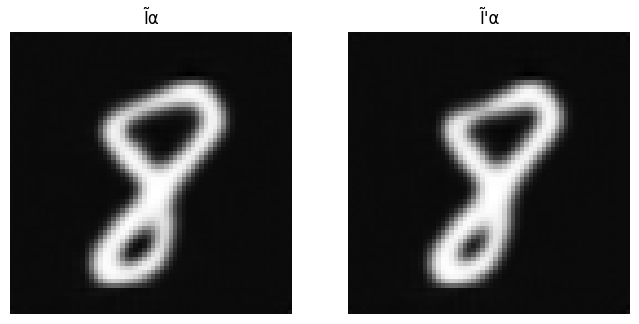

PSNR Value 39.042903900146484 ----- L2 value 6.76249885559082


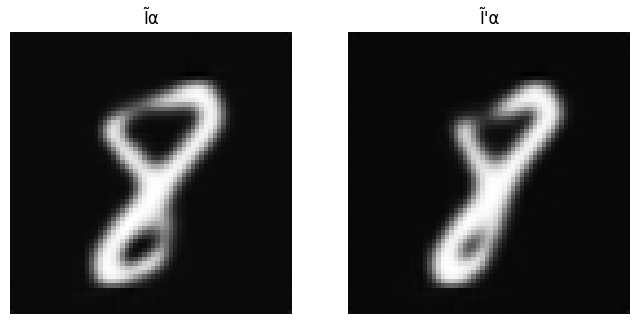

PSNR Value 28.452606201171875 ----- L2 value 12.441268920898438


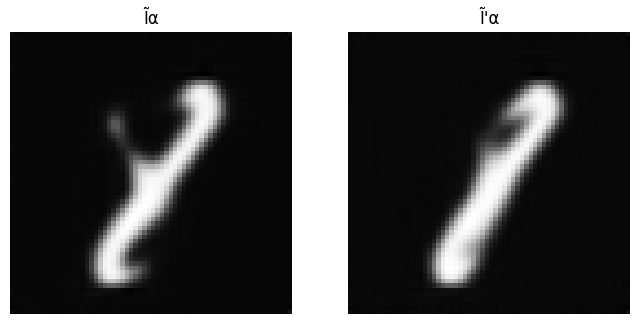

PSNR Value 35.344539642333984 ----- L2 value 8.366933822631836


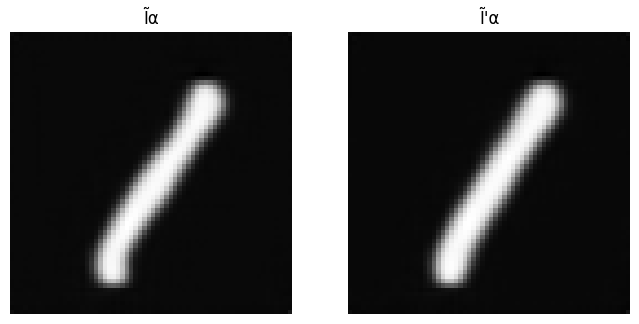

PSNR Value 47.58111572265625 ----- L2 value 4.1366801261901855


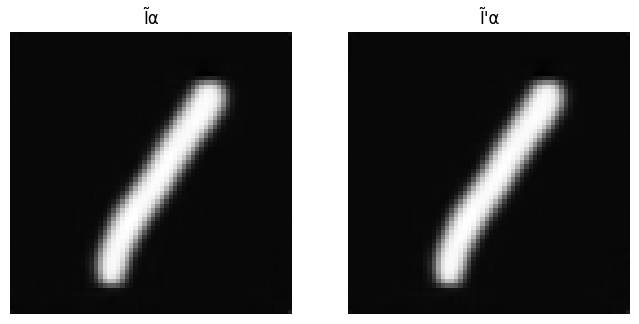

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 12 <--------------------------------



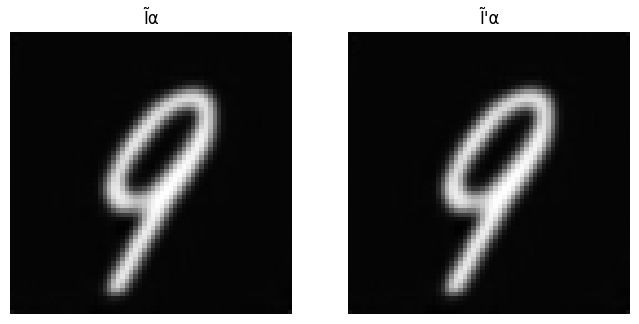

PSNR Value inf ----- L2 value 0.0


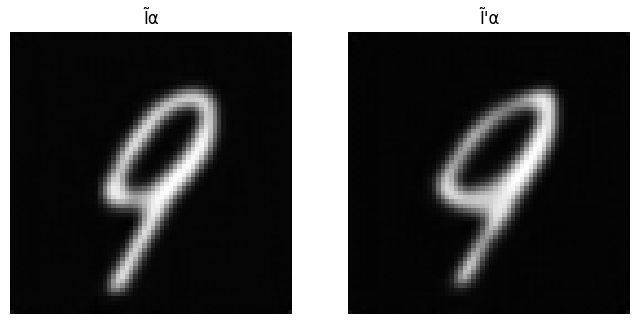

PSNR Value 34.12613296508789 ----- L2 value 8.974836349487305


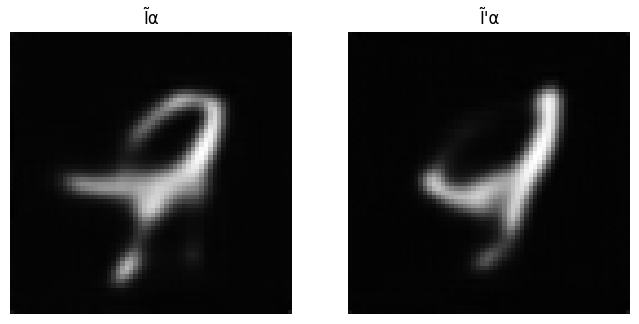

PSNR Value 29.214326858520508 ----- L2 value 11.9075288772583


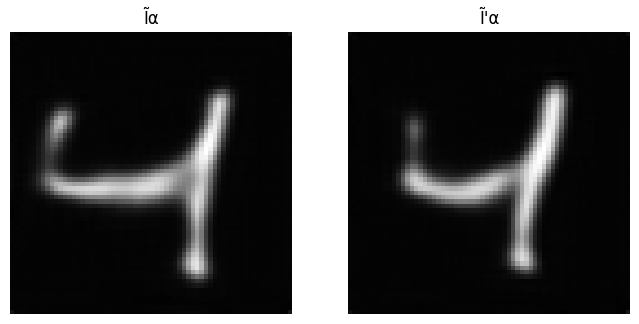

PSNR Value 27.11785125732422 ----- L2 value 13.434874534606934


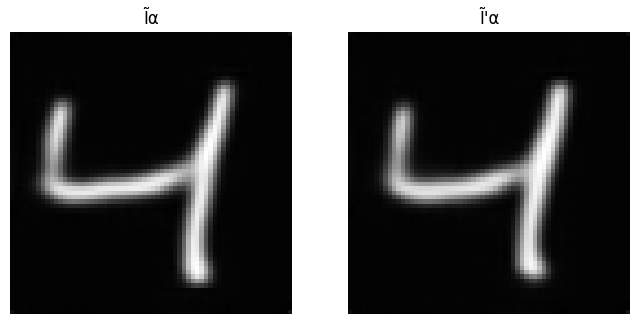

PSNR Value 35.586360931396484 ----- L2 value 8.251269340515137


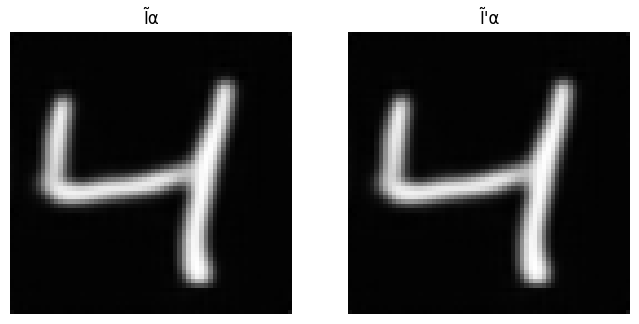

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 13 <--------------------------------



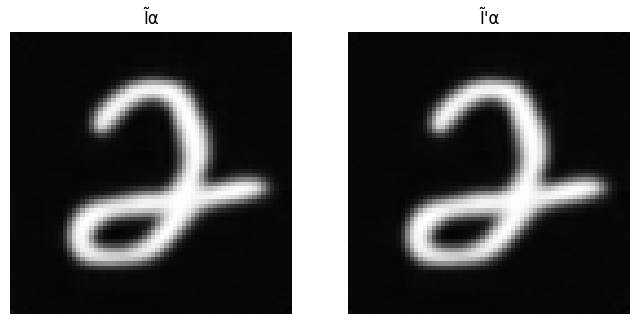

PSNR Value inf ----- L2 value 0.0


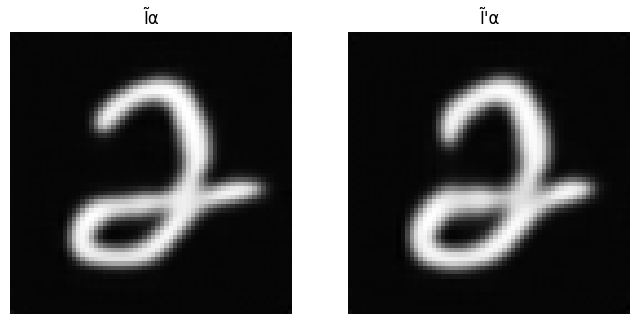

PSNR Value 31.940696716308594 ----- L2 value 10.177999496459961


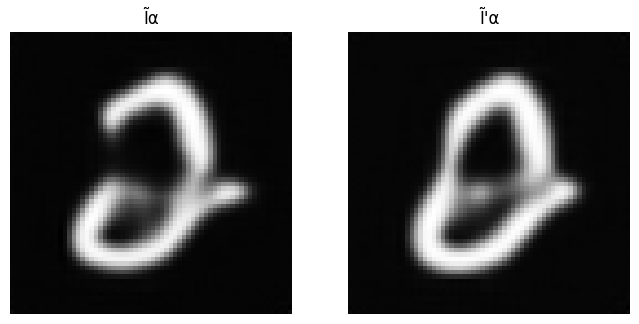

PSNR Value 27.06397819519043 ----- L2 value 13.476600646972656


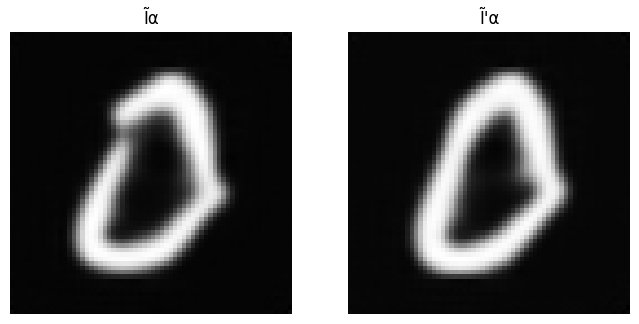

PSNR Value 33.75235366821289 ----- L2 value 9.170036315917969


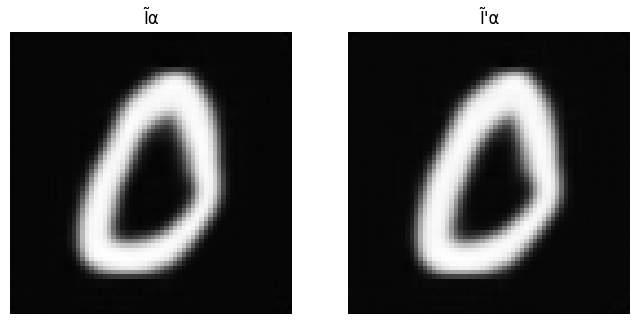

PSNR Value 46.28814697265625 ----- L2 value 4.456317901611328


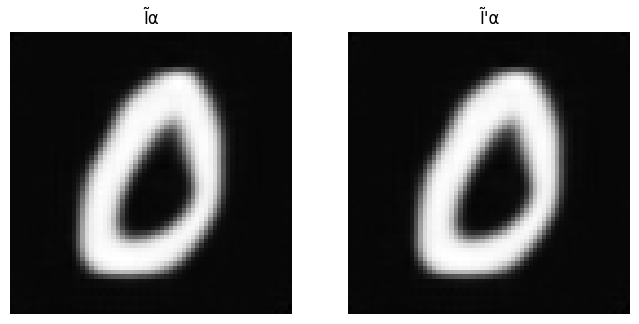

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 14 <--------------------------------



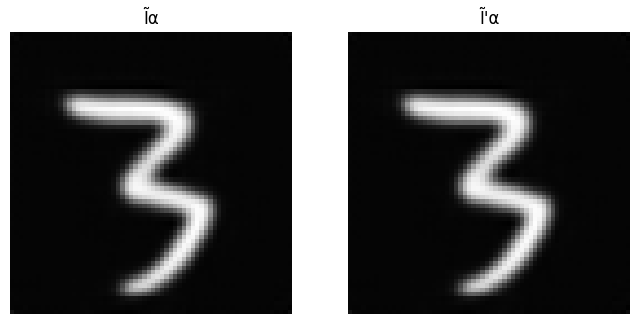

PSNR Value inf ----- L2 value 0.0


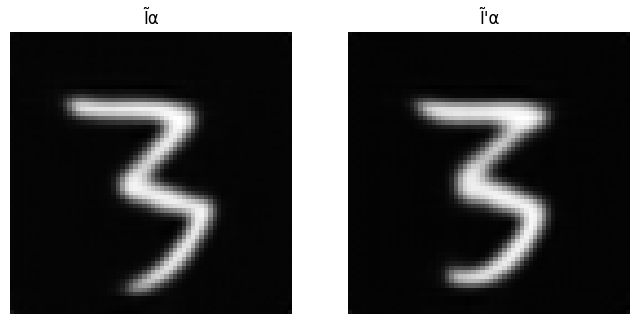

PSNR Value 31.125614166259766 ----- L2 value 10.666933059692383


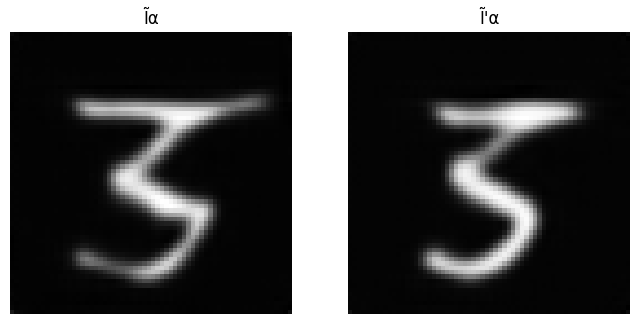

PSNR Value 26.30068016052246 ----- L2 value 14.081953048706055


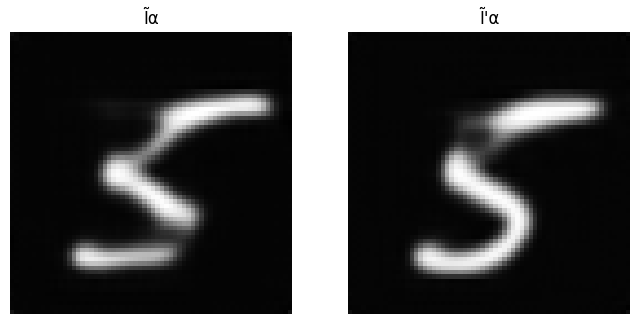

PSNR Value 30.607036590576172 ----- L2 value 10.990159034729004


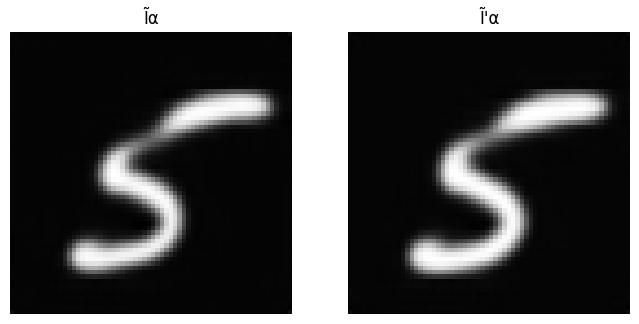

PSNR Value 40.06595230102539 ----- L2 value 6.375748157501221


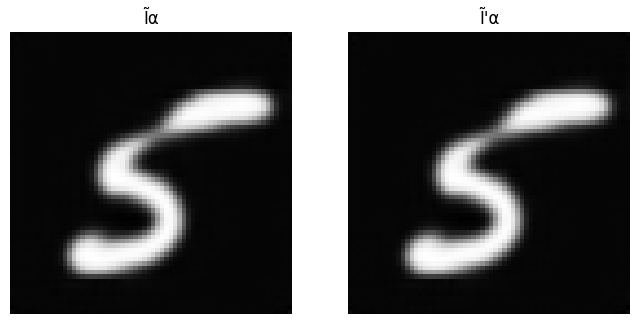

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 15 <--------------------------------



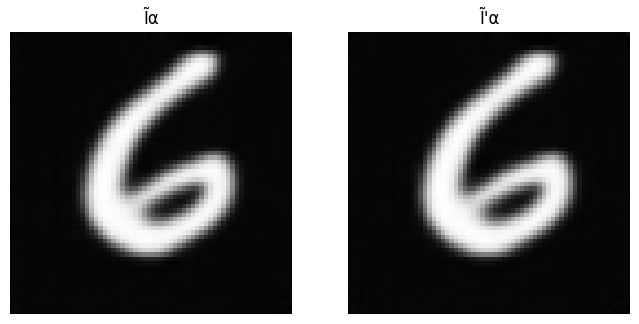

PSNR Value inf ----- L2 value 0.0


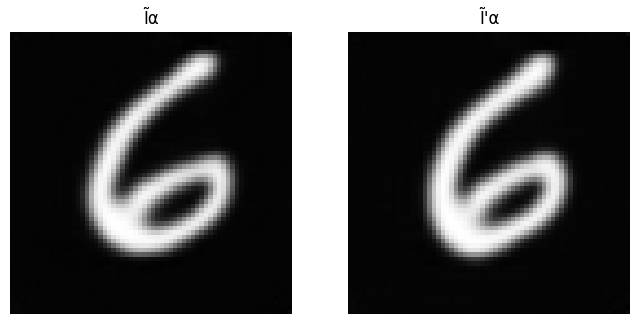

PSNR Value 34.01556396484375 ----- L2 value 9.03214168548584


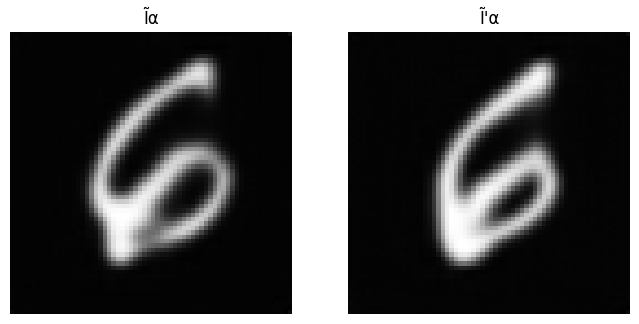

PSNR Value 22.196882247924805 ----- L2 value 17.834369659423828


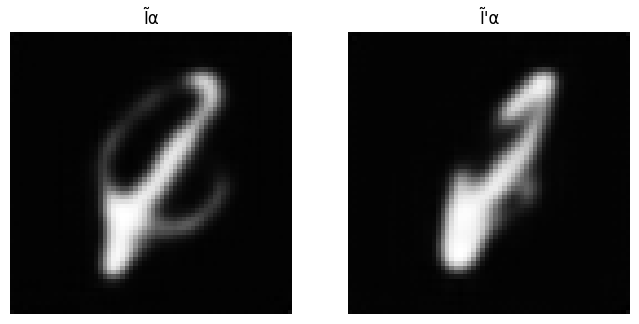

PSNR Value 27.331748962402344 ----- L2 value 13.270463943481445


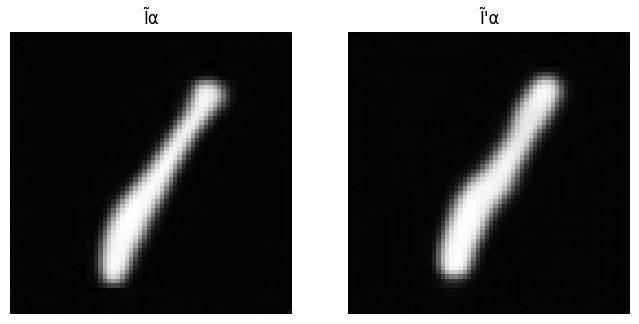

PSNR Value 40.26729965209961 ----- L2 value 6.302274227142334


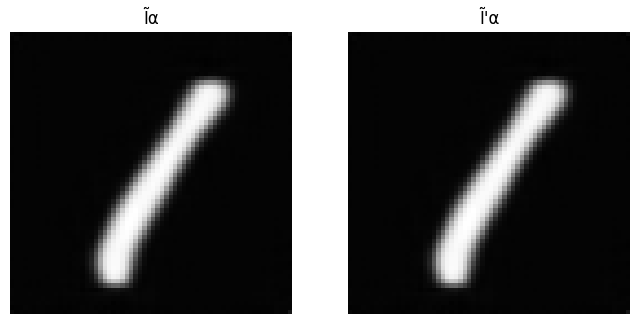

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 16 <--------------------------------



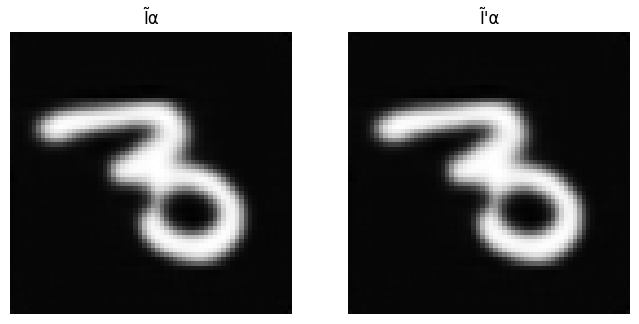

PSNR Value inf ----- L2 value 0.0


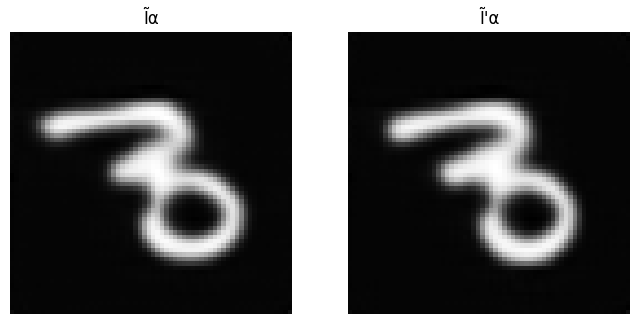

PSNR Value 37.65480041503906 ----- L2 value 7.325037956237793


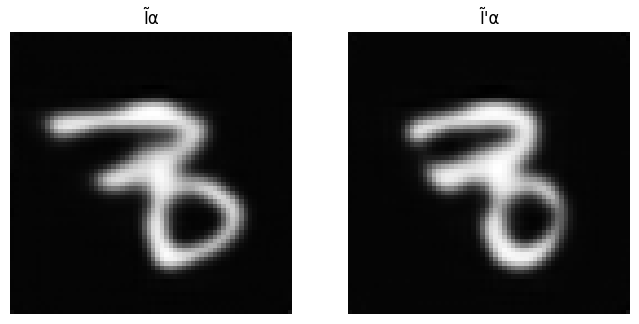

PSNR Value 28.782512664794922 ----- L2 value 12.207226753234863


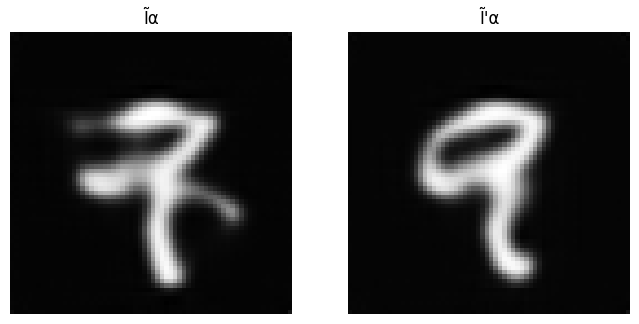

PSNR Value 29.776153564453125 ----- L2 value 11.528586387634277


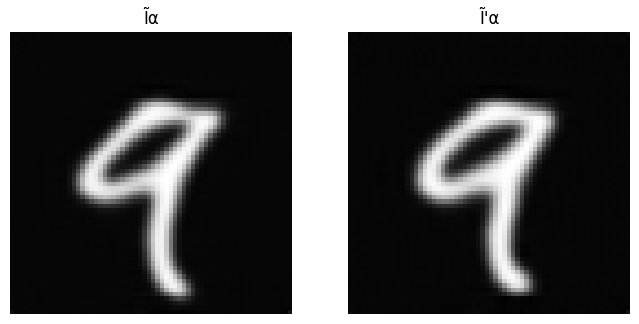

PSNR Value 39.36311340332031 ----- L2 value 6.6389899253845215


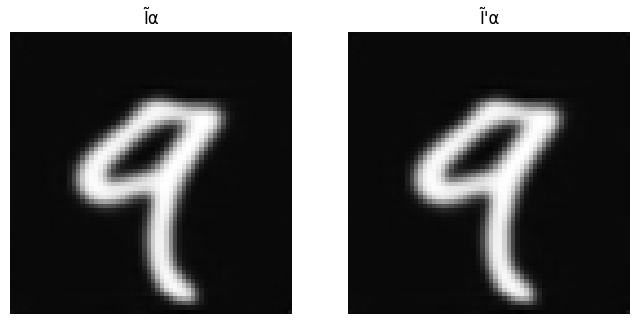

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 17 <--------------------------------



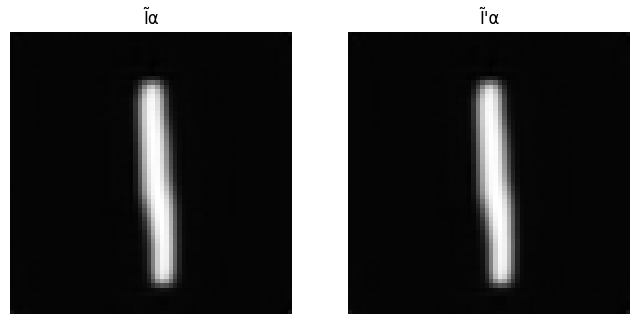

PSNR Value inf ----- L2 value 0.0


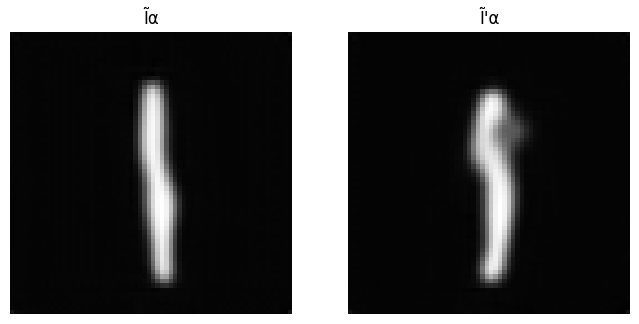

PSNR Value 36.622718811035156 ----- L2 value 7.773416996002197


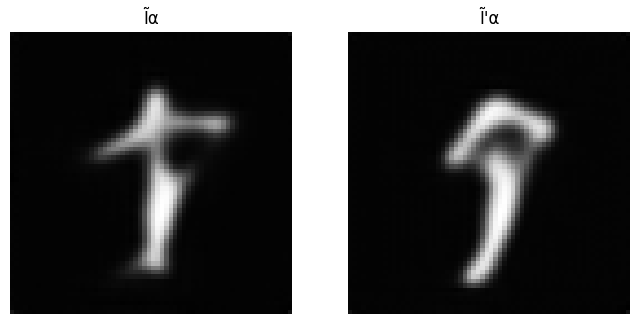

PSNR Value 29.4731502532959 ----- L2 value 11.731433868408203


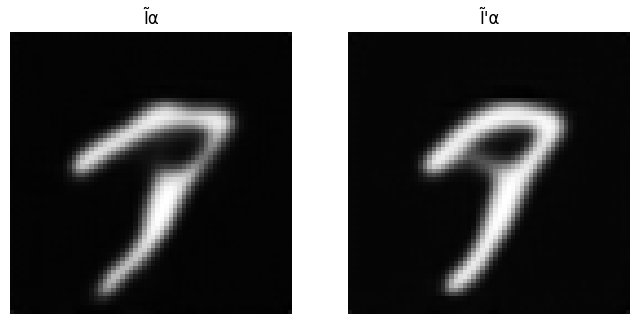

PSNR Value 29.245399475097656 ----- L2 value 11.886248588562012


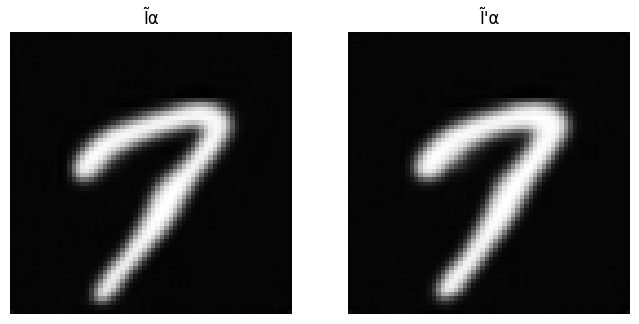

PSNR Value 38.98394775390625 ----- L2 value 6.785490036010742


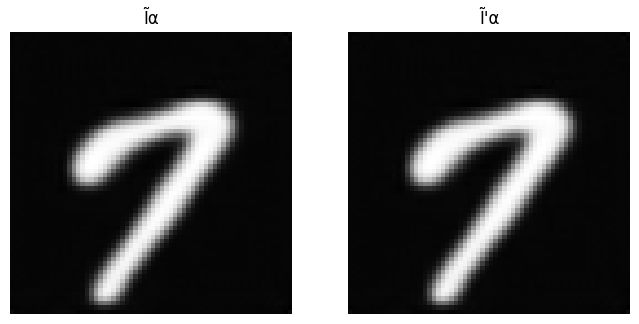

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 18 <--------------------------------



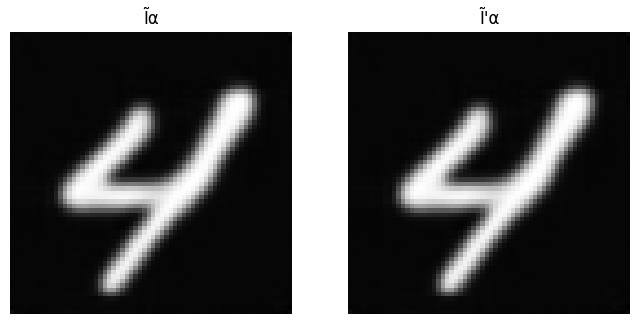

PSNR Value inf ----- L2 value 0.0


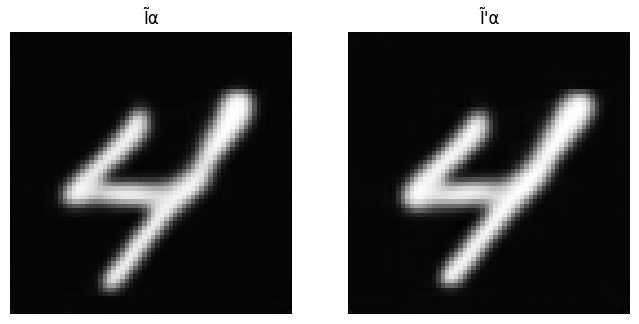

PSNR Value 42.58711242675781 ----- L2 value 5.514448642730713


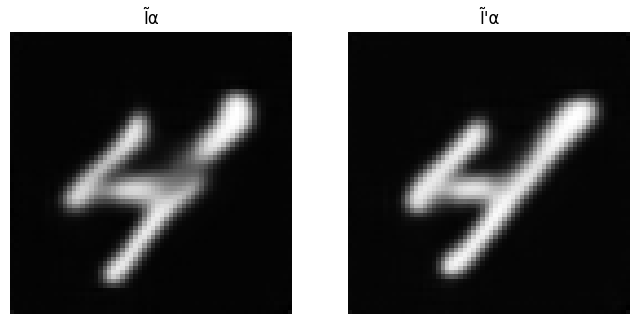

PSNR Value 33.97578811645508 ----- L2 value 9.05284595489502


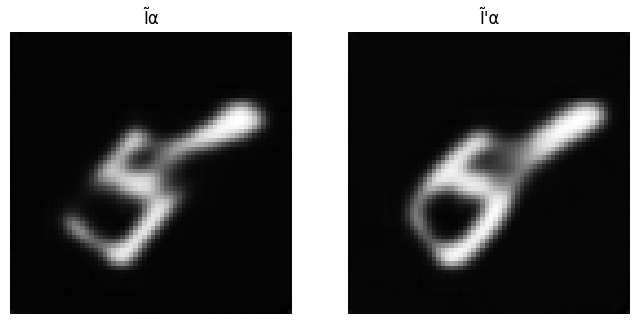

PSNR Value 31.98352813720703 ----- L2 value 10.152936935424805


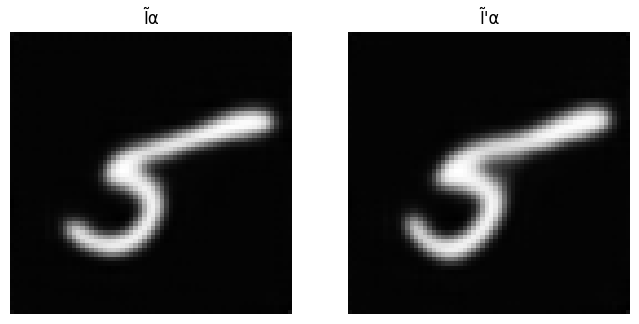

PSNR Value 41.05577850341797 ----- L2 value 6.022618770599365


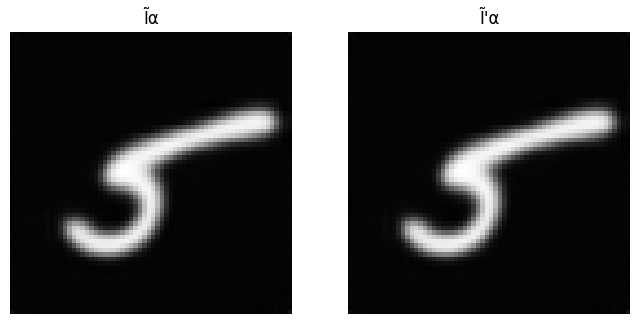

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 19 <--------------------------------



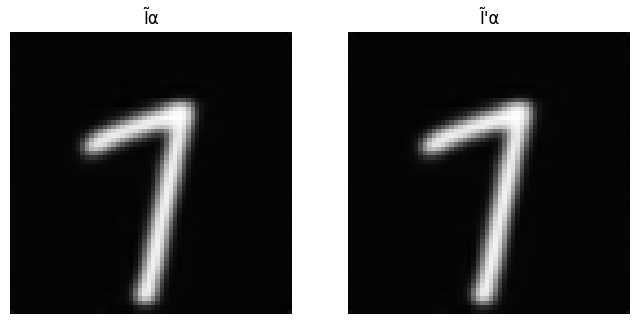

PSNR Value inf ----- L2 value 0.0


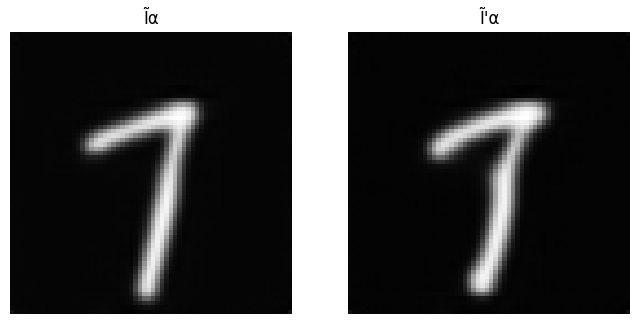

PSNR Value 38.15141296386719 ----- L2 value 7.1185994148254395


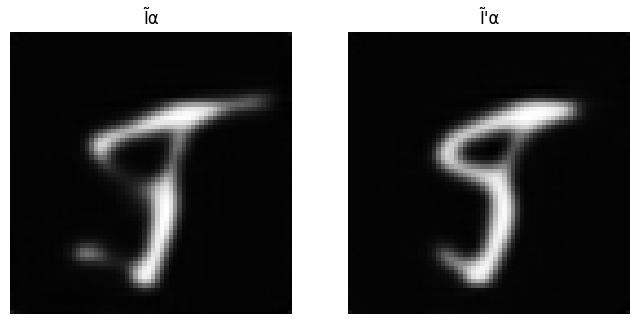

PSNR Value 30.182178497314453 ----- L2 value 11.262256622314453


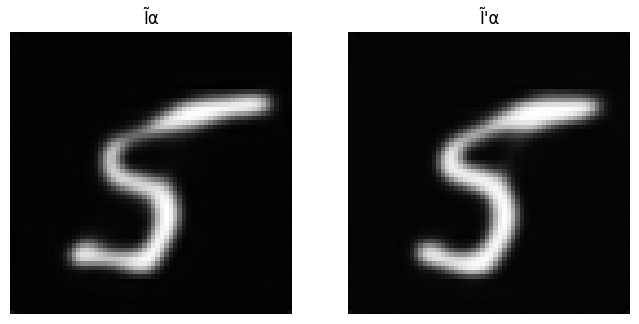

PSNR Value 36.282676696777344 ----- L2 value 7.927074909210205


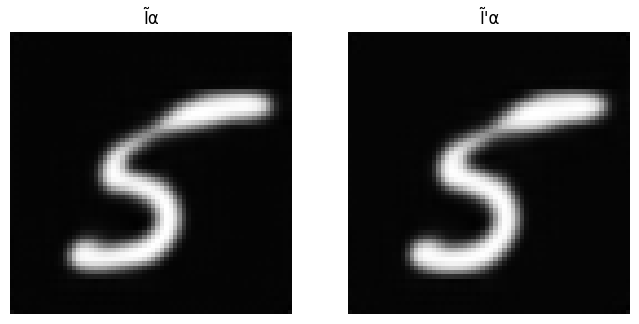

PSNR Value 43.714027404785156 ----- L2 value 5.168079853057861


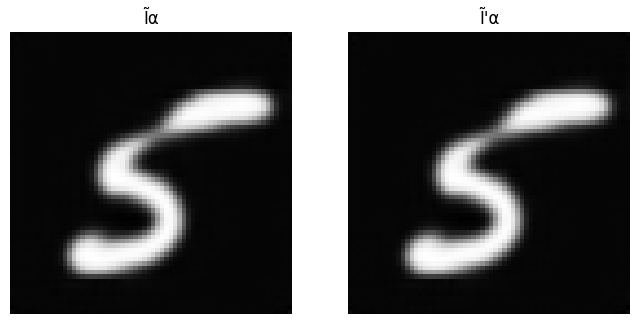

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 20 <--------------------------------



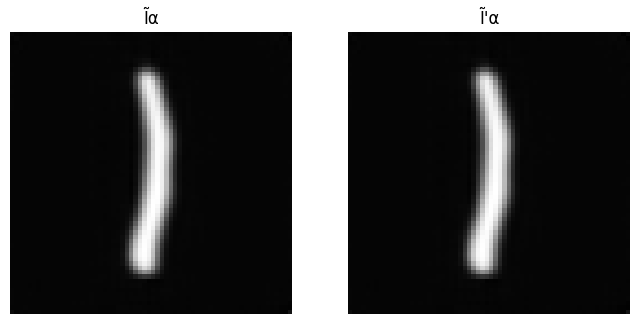

PSNR Value inf ----- L2 value 0.0


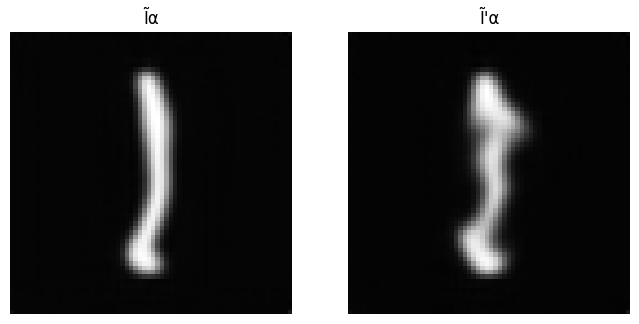

PSNR Value 35.56066131591797 ----- L2 value 8.263484001159668


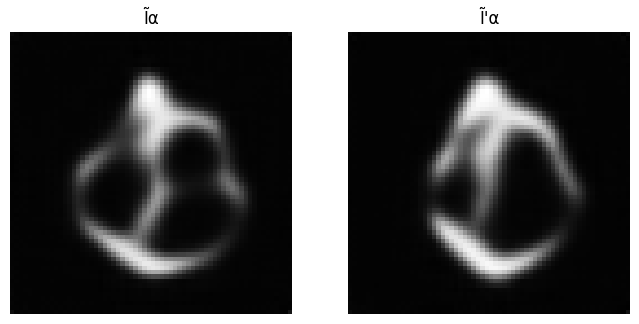

PSNR Value 28.85756492614746 ----- L2 value 12.154603958129883


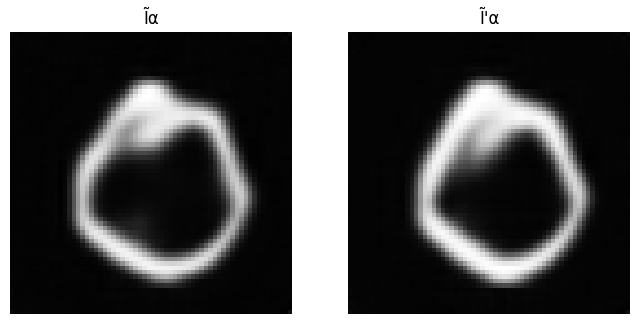

PSNR Value 31.678335189819336 ----- L2 value 10.332883834838867


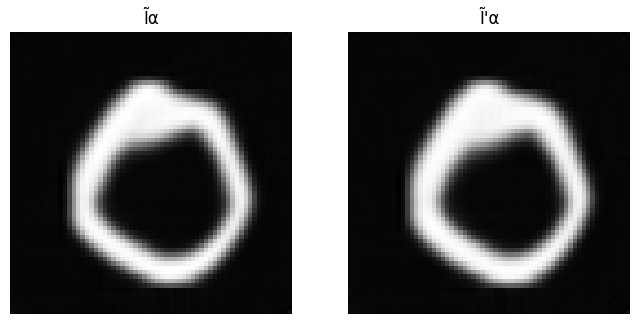

PSNR Value 41.711612701416016 ----- L2 value 5.799487590789795


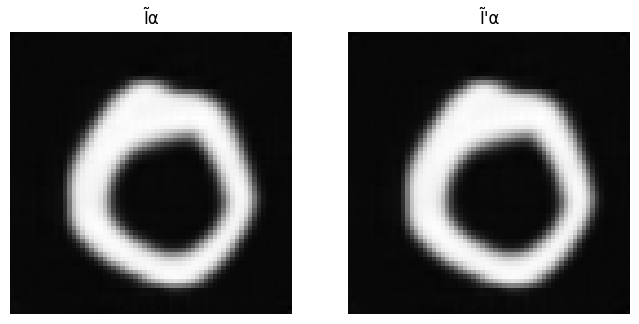

PSNR Value inf ----- L2 value 0.0


In [18]:
alphas=[0, 0.2, 0.4, 0.6, 0.8, 1.]
for i in range(1,21):
    for featues, labels in data_loader_q2:
        if labels[0]!=labels[1]:
            break
        else:
            pass
    print(f'\n--------------------------------> For the image Pair {i} <--------------------------------\n')
    for alpha in alphas:
        I1=featues[0]
        I2=featues[1]

        I_alpha=alpha*I1+(1-alpha)*I2

        model.eval()
        with torch.no_grad():
            # encoder Embeddings
            h_alpha=model.encoder(I_alpha)
            h1=model.encoder(I1)
            h2=model.encoder(I2)
            
            h_dash_alpha=alpha*h1+(1-alpha)*h2

            h_alpha_bottle_neck=model.bottleneck(h_alpha)
            h_dash_alpha_bottle_neck=model.bottleneck(h_dash_alpha)

            i_alpha_hat=model.decoder(h_alpha_bottle_neck)
            i_dash_alpha_hat=model.decoder(h_dash_alpha_bottle_neck)

            psnr=calculate_psnr(i_alpha_hat,i_dash_alpha_hat)
            l2=l2norm(i_alpha_hat,i_dash_alpha_hat)

            # Prepare for plotting
            i_alpha_hat_img = i_alpha_hat.squeeze().cpu().numpy()
            i_dash_alpha__img = i_dash_alpha_hat.squeeze().cpu().numpy()

            # De-normalize if needed (from [-1,1] back to [0,1])
            i_alpha_hat_img = (i_alpha_hat_img * 0.5) + 0.5
            i_dash_alpha__img = (i_dash_alpha__img * 0.5) + 0.5

            # Plot side by side
            plt.figure(figsize=(8,4))

            # Input
            plt.subplot(1,2,1)
            plt.imshow(i_alpha_hat_img, cmap='gray')
            plt.title("Ĩα")
            plt.axis('off')

            # Output
            plt.subplot(1,2,2)
            plt.imshow(i_dash_alpha__img, cmap='gray')
            plt.title("Ĩ'α")
            plt.axis('off')

            plt.show()
            print(f'PSNR Value {psnr} ----- L2 value {l2}')

## (c) (20 points) After training the autoencoders, you want to check if the embeddings of different digits are different and embeddings within a class are similar. For this purpose, you propose to perform the classification of the digits based on the embeddings obtained by the encoders and check the accuracy of classifications for each of the Auto-encoder. Report the classification accuracy for each of the AE and report which one is better. Use any inbuilt classifier to solve the classification problem.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

subset_indices=list(range(3000))
subset_data_set=Subset(train_dataset,subset_indices)
data_loader_q3 = DataLoader(subset_data_set,batch_size=100,shuffle=True)

In [20]:
sample_features=[]
labels=[]
for featues, label in data_loader_q3:
    model.eval()
    with torch.no_grad():
            # encoder Embeddings
            embedded=model.encoder(featues)
            embedded_flat=embedded.view(embedded.size(0),-1)
            sample_features.append(embedded_flat)
            labels.append(label)
sample_features=torch.cat(sample_features,dim=0)
labels=torch.cat(labels,dim=0)   

X_train,X_test,y_train,y_test=train_test_split(sample_features,labels,test_size=0.2,random_state=42)

In [21]:
print(f'Sample Features shape: {sample_features.shape}')
print(f'labels Shape {labels.shape}')

Sample Features shape: torch.Size([3000, 32768])
labels Shape torch.Size([3000])


In [22]:
y_train

tensor([5, 4, 2,  ..., 4, 3, 3])

In [23]:
#Model Definition
log_reg_model=LogisticRegression(max_iter=1000)

#Fit the model
log_reg_model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [25]:
#Predict
y_pred=log_reg_model.predict(X_test)
 
#Evaluate
acc=accuracy_score(y_test,y_pred)

print(f'Accuracy of Classification using Contractive Auto Encoder is: {acc}')

Accuracy of Classification using Contractive Auto Encoder is: 0.9616666666666667


In [ ]:
df=pd.read_csv('AccuracyComparison.csv')
df.drop('Unnamed: 0',axis=1,inplace=True)

data={'model':[],'Time':[],'Accuracy':[]}
start_time = time.time()
start_time=time.strftime('%H:%M:%S', time.gmtime(start_time))
data['Time'].append(start_time)
data['model'].append('Contractive Autoencoder')
data['Accuracy'].append(acc)
df1=pd.DataFrame(data)
df=pd.concat([df,df1])

df.to_csv('AccuracyComparison.csv')

,model,Time,Accuracy
0,Sparse Autoencoder,05:26:58,0.97
0,Sparse Autoencoder,05:27:05,0.97


In [40]:
df

,model,Time,Accuracy
0,Sparse Autoencoder,05:24:52,0.97
0,Sparse Autoencoder,05:24:52,0.97
